wrote /home/fenghuang/workspace/rope-first-principle/assets/attention_diff_diagram.png


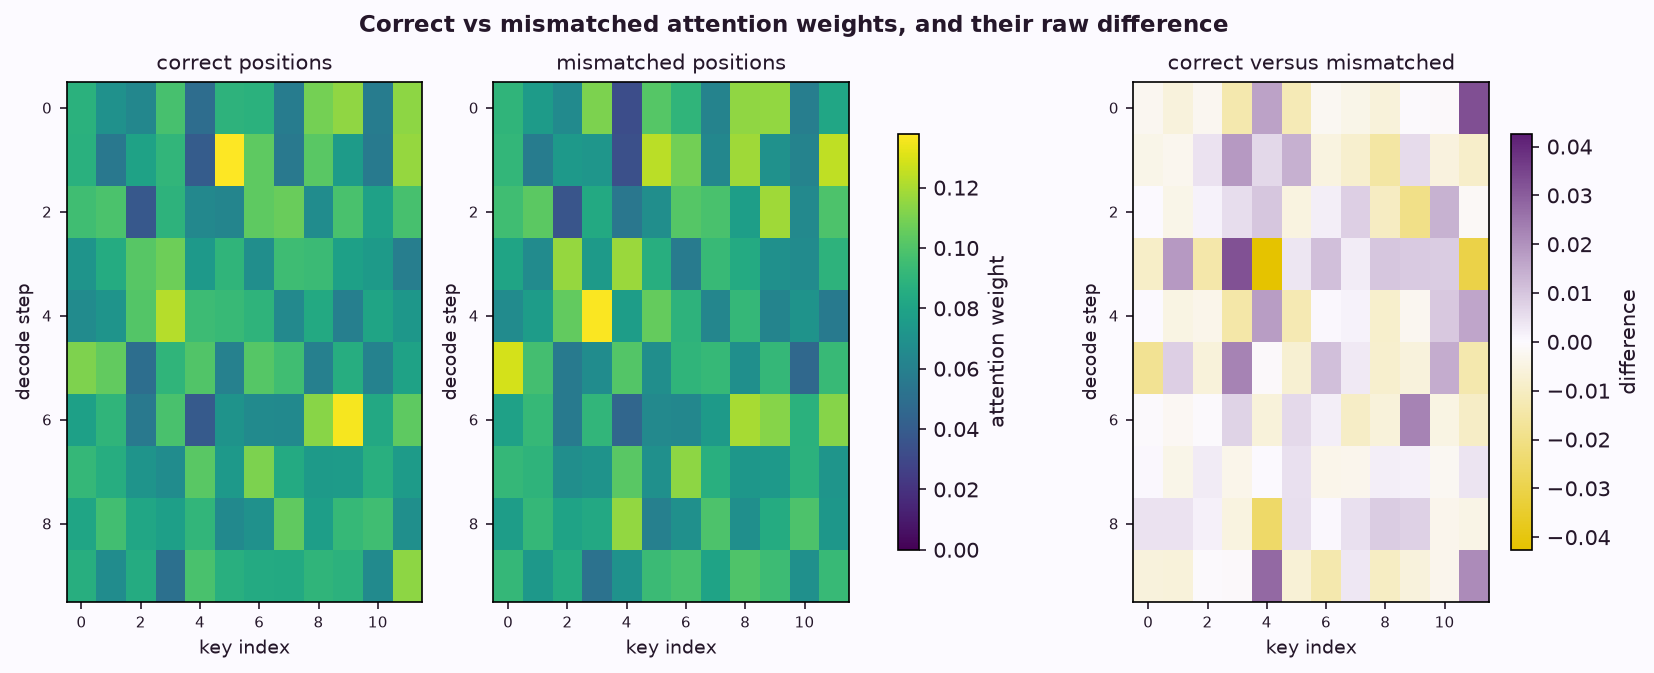

In [5]:
"""Static diagram: third panel for the attention-mismatch scenario, showing
the raw difference between correct and mismatched attention weights.

Reuses the exact same scenario, parameters, and random seed as
anim_attention_mismatch.py (same KV-cache truncation setup), but instead
of animating step by step, this renders the completed weight matrices at
the final decode step, plus a third panel: (correct - mismatched).

That third panel is plotted on its own color scale rather than sharing
the 0..max scale of the first two. Sharing that scale would wash the
difference out, since it is small relative to the raw weights -- this
panel's scale is "amplified" only in the sense that it uses its own full
dynamic range, not because any value is rescaled. The diverging colormap
is built from the brand palette: SECONDARY for negative (mismatched ran
higher), BG_COLOR at zero, PRIMARY for positive (correct ran higher).

Not an animation: single static PNG. Self-contained for Google Colab.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "attention_diff_diagram.png")

# === PALET WARNA BRAND ===
# Panel kiri/tengah tetap viridis (konsisten dengan anim_attention_mismatch.py
# dan alasan yang sama: perceptually uniform untuk nilai kontinu). Panel
# ketiga (diff) pakai colormap diverging custom dari PRIMARY/SECONDARY,
# karena di situ nol punya arti khusus (tidak ada drift) dan harus terlihat
# netral, bukan sekadar titik tengah gradien viridis.
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"

DIFF_CMAP = LinearSegmentedColormap.from_list(
    "brand_diverging", [SECONDARY, BG_COLOR, PRIMARY]
)


def inverse_frequencies(dim: int, base: float = 10000.0) -> np.ndarray:
    i = np.arange(dim // 2)
    return base ** (-2.0 * i / dim)


def apply_rope(x: np.ndarray, position: int, freqs: np.ndarray) -> np.ndarray:
    """Adjacent-pair rotary encoding on a single vector."""
    out = np.empty_like(x)
    angles = position * freqs
    cos, sin = np.cos(angles), np.sin(angles)
    x_even, x_odd = x[0::2], x[1::2]
    out[0::2] = x_even * cos - x_odd * sin
    out[1::2] = x_even * sin + x_odd * cos
    return out


def attention_weights(query: np.ndarray, query_position: int,
                       keys: np.ndarray, key_positions: np.ndarray,
                       freqs: np.ndarray) -> np.ndarray:
    """Softmax attention weights of one query over a fixed set of keys."""
    dim = query.shape[-1]
    q = apply_rope(query, query_position, freqs)
    scores = np.array([
        np.dot(q, apply_rope(keys[j], int(key_positions[j]), freqs))
        for j in range(keys.shape[0])
    ]) / np.sqrt(dim)
    exp = np.exp(scores - scores.max())
    return exp / exp.sum()


def build_diagram(
    dim: int = 16,
    prefix_len: int = 20,
    suffix_len: int = 12,
    n_decode_steps: int = 10,
    seed: int = 0,
    output_path: str = OUTPUT_PATH,
) -> None:
    rng = np.random.default_rng(seed)
    freqs = inverse_frequencies(dim)
    total = prefix_len + suffix_len

    keys = rng.normal(size=(suffix_len, dim)) * 0.5
    queries = rng.normal(size=(n_decode_steps, dim)) * 0.5
    key_positions = np.arange(prefix_len, total)

    weights_correct = np.zeros((n_decode_steps, suffix_len))
    weights_buggy = np.zeros((n_decode_steps, suffix_len))
    for t in range(n_decode_steps):
        weights_correct[t] = attention_weights(
            queries[t], total + t, keys, key_positions, freqs)
        weights_buggy[t] = attention_weights(
            queries[t], suffix_len + t, keys, key_positions, freqs)

    diff = weights_correct - weights_buggy
    vabs = float(np.abs(diff).max())
    vmax_shared = max(weights_correct.max(), weights_buggy.max())

    fig, (ax_l, ax_m, ax_r) = plt.subplots(1, 3, figsize=(13, 4.5), dpi=150)
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle(
        "Correct vs mismatched attention weights, and their raw difference ",
        fontsize=11, color=TEXT_COLOR, fontweight="bold"
    )

    for ax, data, title in ((ax_l, weights_correct, "correct positions"),
                             (ax_m, weights_buggy, "mismatched positions")):
        ax.set_facecolor(BG_COLOR)
        im = ax.imshow(data, vmin=0, vmax=vmax_shared, aspect="auto",
                        cmap="viridis", interpolation="nearest")
        ax.set_title(title, fontsize=10, color=TEXT_COLOR)
        ax.set_xlabel("key index", fontsize=9, color=TEXT_COLOR)
        ax.set_ylabel("decode step", fontsize=9, color=TEXT_COLOR)
        ax.tick_params(labelsize=7, colors=TEXT_COLOR)

    ax_r.set_facecolor(BG_COLOR)
    im_diff = ax_r.imshow(diff, vmin=-vabs, vmax=vabs, aspect="auto",
                           cmap=DIFF_CMAP, interpolation="nearest")
    ax_r.set_title("correct versus mismatched", fontsize=10, color=TEXT_COLOR, fontweight="400")
    ax_r.set_xlabel("key index", fontsize=9, color=TEXT_COLOR)
    ax_r.set_ylabel("decode step", fontsize=9, color=TEXT_COLOR)
    ax_r.tick_params(labelsize=7, colors=TEXT_COLOR)

    cbar_l = fig.colorbar(im, ax=[ax_l, ax_m], shrink=0.8, label="attention weight")
    cbar_l.set_label("attention weight", color=TEXT_COLOR)
    cbar_l.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR)

    cbar_r = fig.colorbar(im_diff, ax=ax_r, shrink=0.8, label="difference")
    cbar_r.set_label("difference", color=TEXT_COLOR)
    cbar_r.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR)

    fig.savefig(output_path, facecolor=BG_COLOR, bbox_inches="tight")
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_diagram()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()


wrote /home/fenghuang/workspace/rope-first-principle/assets/dim_pairing_diagram.png


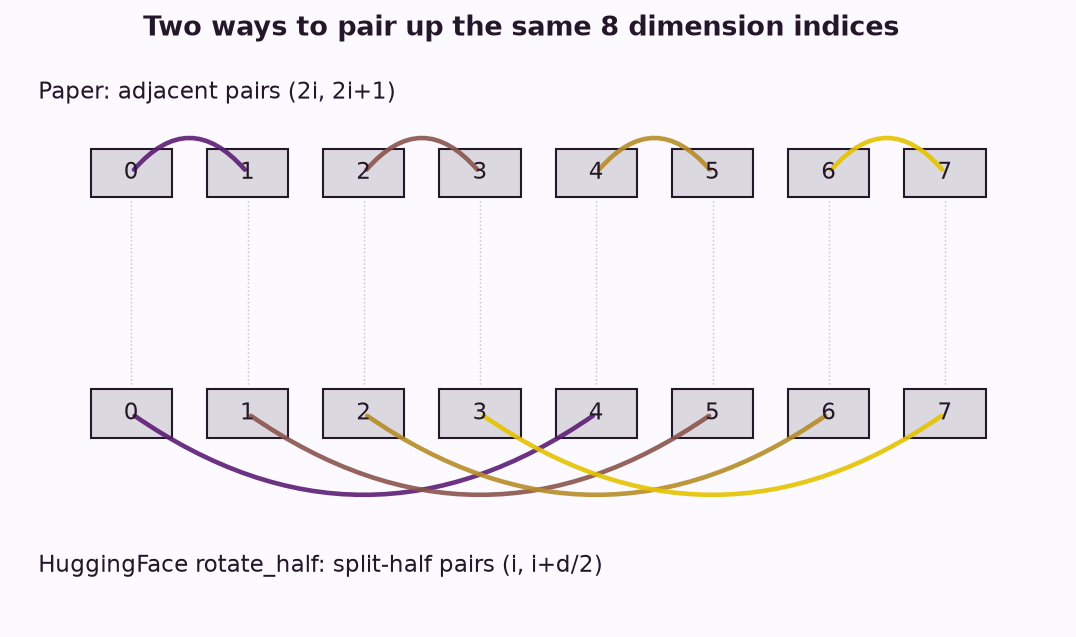

In [25]:
"""Static diagram: which dimension index pairs with which, under each
RoPE convention.

Two rows of index boxes (0..head_dim-1), aligned on the same x-position
so the same physical dimension slot sits directly above/below itself in
both rows. Curved connectors show which two indices are rotated together
as a 2D pair under each convention:

  top row    (paper, adjacent pairs):      (0,1) (2,3) (4,5) (6,7)
  bottom row (HuggingFace rotate_half,
              split-half pairs):           (0,4) (1,5) (2,6) (3,7)

This is a static PNG, not an animation -- the content does not vary over
time, so an animated GIF would add nothing here. Self-contained for
Google Colab: run the whole file in one cell; the image displays inline
and is saved as dim_pairing_diagram.png.
"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "dim_pairing_diagram.png")

# === PALET WARNA BRAND ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def _sequential_palette(n: int, c1: str = PRIMARY, c2: str = SECONDARY) -> list[str]:
    if n <= 1:
        return [c1]
    return [_mix(c1, c2, i / (n - 1)) for i in range(n)]


def _draw_index_row(ax, y: float, head_dim: int, box_w: float = 0.7,
                     box_h: float = 0.6) -> list[tuple[float, float]]:
    """Draw one row of index boxes 0..head_dim-1, return each box's
    (x_center, y) for connector anchoring."""
    centers = []
    for i in range(head_dim):
        x = i
        box = Rectangle((x - box_w / 2, y - box_h / 2), box_w, box_h,
                        facecolor=_mix(TEXT_COLOR, BG_COLOR, 0.85),
                        edgecolor=TEXT_COLOR, linewidth=1.0)
        ax.add_patch(box)
        ax.text(x, y, str(i), ha="center", va="center", fontsize=11,
                color=TEXT_COLOR)
        centers.append((x, y))
    return centers


def _connect(ax, p1: tuple[float, float], p2: tuple[float, float],
             rad: float, color: str) -> None:
    """Curved connector between two box centers, arcing away from the row
    (rad > 0 curves one way, rad < 0 the other -- sign chosen by caller)."""
    arrow = FancyArrowPatch(
        p1, p2, connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-", color=color, linewidth=2.2, alpha=0.9,
    )
    ax.add_patch(arrow)


def build_diagram(
    head_dim: int = 8,
    output_path: str = OUTPUT_PATH,
) -> None:
    paper_pairs = [(i, i + 1) for i in range(0, head_dim, 2)]
    hf_pairs = [(i, i + head_dim // 2) for i in range(head_dim // 2)]
    pair_colors = _sequential_palette(len(paper_pairs))

    fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)
    ax.set_xlim(-1, head_dim)
    ax.set_ylim(-2.6, 4.6)
    ax.axis("off")

    top_y, bottom_y = 3.0, 0.0
    top_centers = _draw_index_row(ax, top_y, head_dim)
    bottom_centers = _draw_index_row(ax, bottom_y, head_dim)

    ax.text(-0.8, top_y + 1, "Paper: adjacent pairs (2i, 2i+1)",
            ha="left", va="center", fontsize=11, color=TEXT_COLOR, fontweight="medium")
    ax.text(-0.8, bottom_y - 1.9, "HuggingFace rotate_half: split-half pairs (i, i+d/2)",
            ha="left", va="center", fontsize=11, color=TEXT_COLOR, fontweight="medium")

    # Paper convention: short arcs curving ABOVE the top row -- pairs are
    # already adjacent, so the connector barely needs to reach.
    for (i, j), color in zip(paper_pairs, pair_colors):
        _connect(ax, top_centers[i], top_centers[j], rad=-0.6, color=color)

    # HuggingFace convention: long arcs curving BELOW the bottom row --
    # pairs span across the two halves, so the connector has to bridge a
    # wide gap. The exaggerated arc height is itself the point: it makes
    # the "reach across halves" visually obvious next to the paper row's
    # short local hops.
    for (i, j), color in zip(hf_pairs, pair_colors):
        _connect(ax, bottom_centers[i], bottom_centers[j], rad=0.35, color=color)

    # Thin vertical guides showing each index sits at the same x in both
    # rows -- same physical slot, different partner depending on convention.
    for x in range(head_dim):
        ax.plot([x, x], [top_y - 0.35, bottom_y + 0.35],
                color=_mix(TEXT_COLOR, BG_COLOR, 0.75), linewidth=0.7,
                linestyle=":", zorder=0)

    fig.suptitle(
        "Two ways to pair up the same 8 dimension indices",
        fontsize=13, color=TEXT_COLOR, y=0.92, fontweight="bold",
    )

    fig.savefig(output_path, facecolor=BG_COLOR, bbox_inches="tight")
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_diagram()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

wrote /home/fenghuang/workspace/rope-first-principle/assets/score_matrix_rope_comparison.png


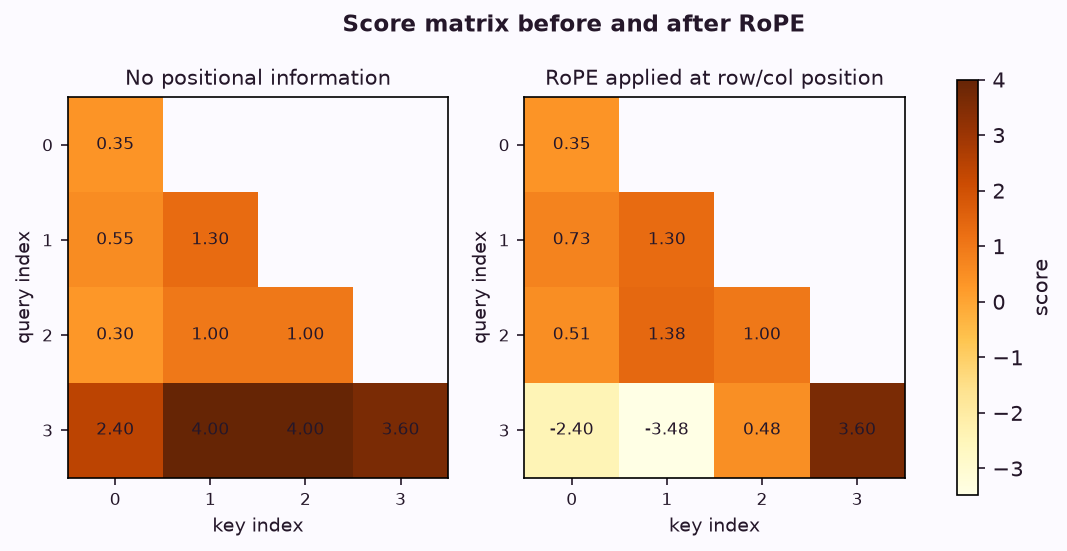

In [ ]:
"""Static diagram: the same Q/K score matrix from section 6, before and
after RoPE is applied.

Left panel reproduces the raw Q.K^T matrix used in the notebook's score
matrix example (no positional information, identical vectors to
anim_score_matrix.py). Right panel applies RoPE to each Q_t and K_j at
its row/column index before taking the dot product. Same vectors, same
causal mask, same color scale shared across both panels -- a color
difference at the same cell is a real value difference, not an artifact
of two independently-scaled colormaps.

Not an animation: single static PNG. Self-contained for Google Colab.
"""

import matplotlib.pyplot as plt
import numpy as np

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "score_matrix_rope_comparison.png")

PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"


def inverse_frequencies(dim: int, base: float = 10000.0) -> np.ndarray:
    i = np.arange(dim // 2)
    return base ** (-2.0 * i / dim)


def apply_rope_adjacent(x: np.ndarray, position: int, freqs: np.ndarray) -> np.ndarray:
    """Adjacent-pair rotary encoding on a single vector."""
    out = np.empty_like(x)
    angles = position * freqs
    cos, sin = np.cos(angles), np.sin(angles)
    x_even, x_odd = x[0::2], x[1::2]
    out[0::2] = x_even * cos - x_odd * sin
    out[1::2] = x_even * sin + x_odd * cos
    return out


def build_diagram(output_path: str = OUTPUT_PATH) -> None:
    # Same vectors as the notebook's section 6 example.
    q_vectors = np.array([[0.0, 0.5],
                          [0.9, 0.4],
                          [1.0, 0.0],
                          [1.0, 3.0]])
    k_vectors = np.array([[0.3, 0.7],
                          [1.0, 1.0],
                          [1.0, 1.0],
                          [0.6, 1.0]])
    n = len(q_vectors)
    freqs = inverse_frequencies(2)  # dim=2 -> one plane, theta_0 = 1.0

    scores_raw = q_vectors @ k_vectors.T
    q_rot = np.stack([apply_rope_adjacent(q_vectors[t], t, freqs) for t in range(n)])
    k_rot = np.stack([apply_rope_adjacent(k_vectors[j], j, freqs) for j in range(n)])
    scores_rope = q_rot @ k_rot.T

    mask = np.tril(np.ones((n, n), dtype=bool))
    masked_raw = np.where(mask, scores_raw, np.nan)
    masked_rope = np.where(mask, scores_rope, np.nan)

    vmin = float(np.nanmin([masked_raw, masked_rope]))
    vmax = float(np.nanmax([masked_raw, masked_rope]))

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(9, 4.5), dpi=150)
    fig.patch.set_facecolor(BG_COLOR)
    fig.suptitle("Score matrix before and after RoPE",
                 fontsize=11, color=TEXT_COLOR, fontweight="bold", y=0.90)

    im = None
    for ax, data, title in ((ax_l, masked_raw, "No positional information"),
                             (ax_r, masked_rope, "RoPE applied at row/col position")):
        ax.set_facecolor(BG_COLOR)
        im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap="YlOrBr")
        ax.set_title(title, fontsize=10, color=TEXT_COLOR)
        ax.set_xlabel("key index", fontsize=9, color=TEXT_COLOR, fontweight="medium")
        ax.set_ylabel("query index", fontsize=9, color=TEXT_COLOR, fontweight="medium")
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.tick_params(colors=TEXT_COLOR, labelsize=8)
        for t in range(n):
            for j in range(n):
                if mask[t, j]:
                    ax.text(j, t, f"{data[t, j]:.2f}", ha="center", va="center",
                            fontsize=8, color=TEXT_COLOR)

    cbar = fig.colorbar(im, ax=[ax_l, ax_r], shrink=0.8)
    cbar.set_label("score", color=TEXT_COLOR)
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR)

    fig.savefig(output_path, facecolor=BG_COLOR, bbox_inches="tight")
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_diagram()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()